<a href="https://colab.research.google.com/github/jessica-ostaChrist28/Spam-Email-Detector/blob/main/Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [1]:
import pandas as pd

# Use the link you copied in Step 3
url = 'https://raw.githubusercontent.com/jessica-ostaChrist28/Spam-Email-Detector/refs/heads/main/spam_ham_dataset.csv'
data = pd.read_csv(url)

data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [4]:
data.shape


(5171, 4)

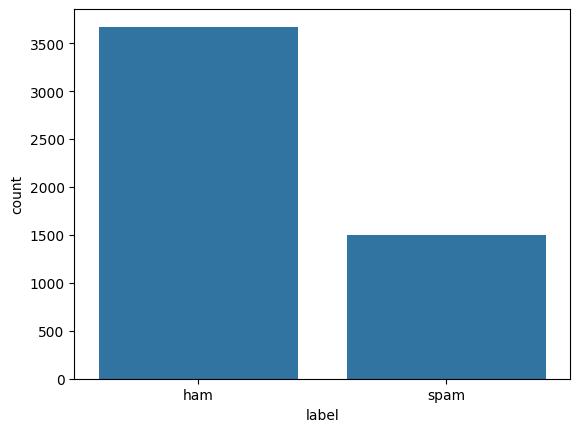

In [5]:
sns.countplot(x='label', data=data)
plt.show()

**Data Inbalance**-

* If 80% of your data is Ham and 20% is Spam, a model could simply guess "Ham" for every single email and still be 80% accurate without actually learning anything.

* If the dataset is imbalanced, the model’s mathematical loss function will prioritize getting the "Ham" emails right because they make up the bulk of the data. Downsampling ensures the model gives equal weight to the characteristics of Spam.

* the decision boundary is place fairly and better F1-Score










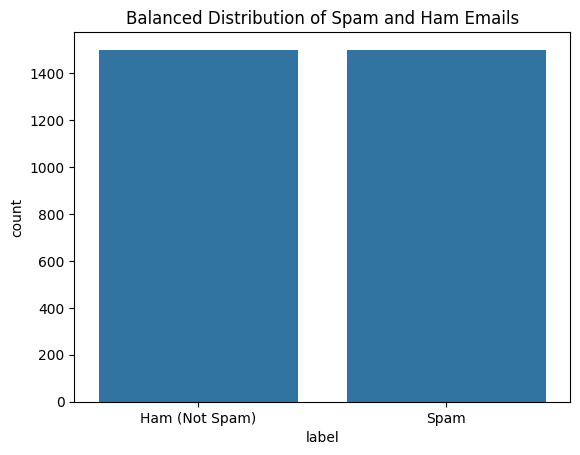

In [6]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

# Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

# Visualize the balanced dataset
sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.xticks(ticks=[0, 1], labels=['Ham (Not Spam)', 'Spam'])
plt.show()

In [7]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


**Notice**:
That \r\n (which represents a new line) is still there. While the punctuation is gone, those "hidden" formatting characters remain

In [8]:
punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)

balanced_data['text']= balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


**Notice:**
It removes the most common, unhelpful words in the English language so the AI can focus on the "red flag" words that actually indicate spam.

In [9]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')

    imp_words = []

    # Storing the important words
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)

    output = " ".join(imp_words)

    return output


balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


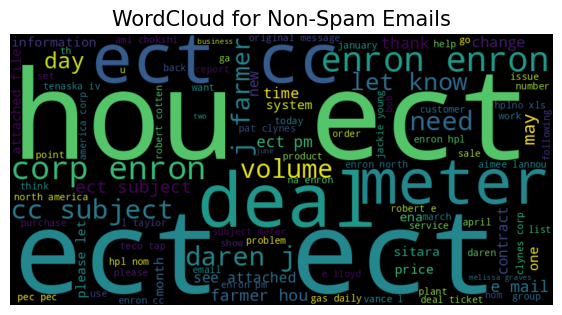

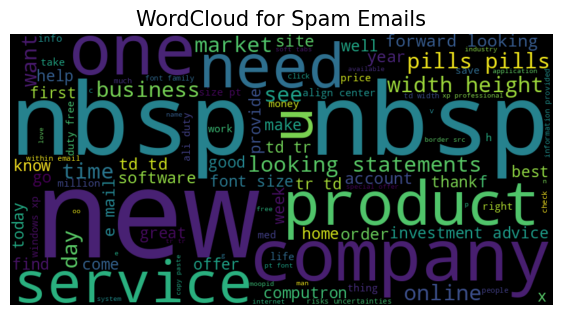

In [10]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

In [12]:
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100  # Maximum sequence length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

In [15]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9458 - loss: 0.1918 - val_accuracy: 0.9267 - val_loss: 0.2364 - learning_rate: 2.5000e-04
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9408 - loss: 0.1930 - val_accuracy: 0.9350 - val_loss: 0.2168 - learning_rate: 2.5000e-04
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9433 - loss: 0.1855 - val_accuracy: 0.9350 - val_loss: 0.2170 - learning_rate: 2.5000e-04
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9437 - loss: 0.1843 - val_accuracy: 0.9317 - val_loss: 0.2242 - learning_rate: 2.5000e-04
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9479 - loss: 0.1744 - val_accuracy: 0.9367 - val_loss: 0.2217 - learning_rate: 1.2500e-04
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9512 - loss: 0.1680 - val_accuracy: 0.9367 - val_loss: 0.2220 - learning_rate: 1.2500e-04
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9512 

In [20]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9367 - loss: 0.2217
Test Loss : 0.2217358946800232
Test Accuracy : 0.9366666674613953


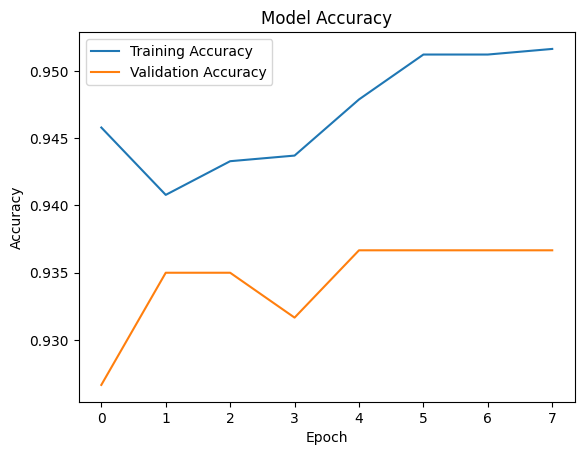

In [21]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [23]:
def predict_spam(new_emails):
    # 1. Clean the text (Punctuation & Stopwords)
    cleaned_emails = [remove_stopwords(remove_punctuations(email)) for email in new_emails]

    # 2. Tokenize and Pad
    sequences = tokenizer.texts_to_sequences(cleaned_emails)
    padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

    # 3. Predict
    predictions = model.predict(padded)

    for i, prob in enumerate(predictions):
        label = "SPAM" if prob > 0.5 else "HAM"
        print(f"Email {i+1}: {label} ({prob[0]*100:.2f}% certainty)")

# --- TRY IT OUT HERE ---
my_emails = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!",
    "Hey, are we still meeting for coffee at 3 PM today? Let me know.",
    "URGENT: Your account has been compromised. Please log in immediately to verify your identity."
]

predict_spam(my_emails)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Email 1: SPAM (88.58% certainty)
Email 2: SPAM (88.58% certainty)
Email 3: SPAM (88.58% certainty)


In [27]:
def predict_spam(new_emails):
    # 1. Clean the text (Punctuation & Stopwords)
    cleaned_emails = [remove_stopwords(remove_punctuations(email)) for email in new_emails]

    # 2. Tokenize and Pad
    sequences = tokenizer.texts_to_sequences(cleaned_emails)
    padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

    # 3. Predict
    predictions = model.predict(padded)

    for i, prob in enumerate(predictions):
        label = "SPAM" if prob > 0.5 else "HAM"
        print(f"Email {i+1}: {label} ({prob[0]*100:.2f}% certainty)")

# --- TRY IT OUT HERE ---
my_emails = ["""
JESSICA JOHN OSTA 2460376 <jessica.john@btech.christuniversity.in>
Attachments
Wed, Oct 23, 2024, 8:43 AM
to br0487

Good afternoon sir/madam,

From past one week I am facing an issue while paying through my SIB app.
Whenever I am scaning any QR while paying it is always showing this (the picture uploaded).
I would request if you could kindly help me with this problem. Please suggest some ways by which I can fix this problem.
I am facing alot of problem everyday because of this.

Thankyou
Jessica John Osta
Student at Christ University, Kengeri

"""

]

predict_spam(my_emails)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Email 1: SPAM (88.58% certainty)
